# Floyd-Warshall: CPU vs GPU Experiments

## Aim

The goal of this notebook is to implement and compare different versions of the
Floyd-Warshall all-pairs shortest path algorithm:

1. **Variant 1 (CPU Baseline):** A sequential NumPy implementation taken from R2.
2. **Variant 2 (GPU Baseline):** A naive Numba CUDA kernel taken from R2, where each thread updates one cell (i, j) per k-step using a 16x16 block size.
3. **Variant 3 (GPU Modernized):** An improved Numba CUDA kernel that uses a larger 32x32 block size and shared-memory tiling to reduce redundant global memory reads.
4. **Variant 4 (CuPy Broadcasting):** A CuPy-based GPU implementation that mirrors the NumPy broadcasting approach but runs entirely on the GPU.

We run all four variants on increasing problem sizes (n = 256, 512, 1024, 2048)
and compare wall-clock runtimes, speedups, and discuss bottlenecks.

**Reference implementations:**
- R1: `floyd_warshall_cuda.cu` (C++/CUDA, used for design reference)
- R2: `floyd_warshall_fwp_cuda.ipynb` (NumPy + Numba CUDA, our starting point)

---
## Cell 1: Imports, Constants, and Graph Generator

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt
from numba import cuda, float32
import cupy as cp

# A large number representing "no edge" (infinity)
INF = 1e20

def generate_random_graph(num_nodes, edge_probability=0.6, max_weight=10.0, seed=42):
    """
    Generate a random dense directed graph as an adjacency matrix.

    - num_nodes: number of vertices in the graph
    - edge_probability: chance that an edge exists between any two nodes
    - max_weight: maximum edge weight (minimum is 1.0)
    - seed: random seed for reproducibility

    Returns an (num_nodes x num_nodes) float32 matrix where:
      - diagonal entries are 0 (distance from a node to itself)
      - off-diagonal entries are either a random weight or INF (no edge)
    """
    rng = np.random.default_rng(seed)

    # Start with all distances set to INF (no edges)
    weight_matrix = np.full((num_nodes, num_nodes), INF, dtype=np.float32)

    for i in range(num_nodes):
        # Distance from any node to itself is 0
        weight_matrix[i, i] = 0.0
        for j in range(num_nodes):
            if i != j and rng.random() < edge_probability:
                # Assign a random weight between 1.0 and max_weight
                weight_matrix[i, j] = rng.uniform(1.0, max_weight)

    return weight_matrix

# Quick test: generate a small graph and print it
test_graph = generate_random_graph(4)
print("Sample 4-node graph:")
print(test_graph)
print("\nCUDA available:", cuda.is_available())
print("CuPy version:", cp.__version__)

Sample 4-node graph:
[[0.0000000e+00 1.0000000e+20 8.7273817e+00 1.0000000e+20]
 [9.7806015e+00 0.0000000e+00 1.0000000e+20 1.0000000e+20]
 [5.0534735e+00 9.3408852e+00 0.0000000e+00 1.0000000e+20]
 [1.0000000e+20 3.0451486e+00 1.5743554e+00 0.0000000e+00]]

CUDA available: True
CuPy version: 14.0.1


---
## Cell 2: Variant 1 — NumPy CPU Baseline (from R2)

This is the sequential CPU baseline taken directly from R2.
It uses NumPy broadcasting to update the entire matrix at each k-step.

For each intermediate node k:
- Extract column k as a column vector (shape n x 1)
- Extract row k as a row vector (shape 1 x n)
- Compute D = min(D, column_k + row_k) using broadcasting

This is equivalent to the triple-loop version but much faster in Python
because NumPy handles the inner two loops in optimized C code.

In [7]:
# ============================================================
# VARIANT 1: Sequential CPU baseline (from R2)
# Source: R2, cell 3 — floyd_warshall_numpy
# ============================================================

def floyd_warshall_cpu(weight_matrix):
    """
    Floyd-Warshall using NumPy broadcasting (sequential CPU).

    For each intermediate node k, we check if going through k
    gives a shorter path: D[i][j] = min(D[i][j], D[i][k] + D[k][j])

    The broadcasting trick:
      D[:, k][:, None]  -> column k reshaped to (n, 1) so it broadcasts across columns
      D[k, :][None, :]  -> row k reshaped to (1, n) so it broadcasts across rows
      Adding them gives an (n, n) matrix of D[i][k] + D[k][j] for all (i,j)
    """
    dist = weight_matrix.copy().astype(np.float32)
    num_nodes = dist.shape[0]

    for k in range(num_nodes):
        # Get column k (all rows, column k) as a column vector
        dist_ik = dist[:, k][:, None]   # shape: (n, 1)
        # Get row k (row k, all columns) as a row vector
        dist_kj = dist[k, :][None, :]   # shape: (1, n)
        # Update: take element-wise minimum of current distance vs going through k
        dist = np.minimum(dist, dist_ik + dist_kj)

    return dist

# Quick correctness test on a small known graph
small_graph = np.array([
    [0,    3,    INF,  7  ],
    [8,    0,    2,    INF],
    [5,    INF,  0,    1  ],
    [2,    INF,  INF,  0  ]
], dtype=np.float32)

cpu_result = floyd_warshall_cpu(small_graph)
print("CPU result on 4-node test graph:")
print(cpu_result)

CPU result on 4-node test graph:
[[0. 3. 5. 6.]
 [5. 0. 2. 3.]
 [3. 6. 0. 1.]
 [2. 5. 7. 0.]]


---
## Cell 3: Variant 2 — Naive Numba CUDA Kernel (from R2)

This is the GPU baseline taken from R2. It mirrors the CUDA C++ kernel in R1.

**How it works:**
- For each k-step, we launch a 2D grid of threads covering the entire n x n matrix
- Each thread handles exactly one cell (i, j)
- Each thread reads D[i][k] and D[k][j] from global memory and updates D[i][j]
- Block size is 16x16 (same as R1 and R2)

**Limitations:**
- No shared memory usage — every thread reads from slow global memory independently
- Many redundant reads (threads in the same row all read the same D[i][k])

In [8]:
# ============================================================
# VARIANT 2: Naive Numba CUDA kernel (from R2)
# Source: R2, cell 5 — floyd_step_kernel and floyd_warshall_numba_cuda
# ============================================================

@cuda.jit
def naive_floyd_kernel(dist_matrix, num_nodes, k):
    """
    Naive GPU kernel: one thread per (i, j) cell.
    Each thread checks if going through node k gives a shorter path.
    Reads D[i][k] and D[k][j] directly from global memory.
    """
    # Calculate which cell (i, j) this thread is responsible for
    i, j = cuda.grid(2)

    # Boundary check: skip if outside the matrix
    if i < num_nodes and j < num_nodes:
        # Read the two distances needed for the update
        dist_i_to_k = dist_matrix[i, k]  # distance from i to k
        dist_k_to_j = dist_matrix[k, j]  # distance from k to j

        # Path through k
        path_through_k = dist_i_to_k + dist_k_to_j

        # Update if the path through k is shorter
        if path_through_k < dist_matrix[i, j]:
            dist_matrix[i, j] = path_through_k


def floyd_warshall_gpu_naive(weight_matrix):
    """
    Run Floyd-Warshall on GPU using the naive kernel (16x16 blocks).

    Steps:
    1. Copy the distance matrix to GPU memory
    2. For each k from 0 to n-1, launch the kernel
    3. After all k steps, copy the result back to CPU
    """
    dist_host = weight_matrix.astype(np.float32)
    num_nodes = dist_host.shape[0]

    # Copy matrix to GPU (device) memory
    dist_device = cuda.to_device(dist_host)

    # Block size: 16x16 threads per block (from R1/R2)
    threads_per_block = (16, 16)
    # Grid size: enough blocks to cover the entire n x n matrix
    blocks_per_grid = (
        (num_nodes + threads_per_block[0] - 1) // threads_per_block[0],
        (num_nodes + threads_per_block[1] - 1) // threads_per_block[1]
    )

    # Launch one kernel per k-step (k cannot be parallelized)
    for k in range(num_nodes):
        naive_floyd_kernel[blocks_per_grid, threads_per_block](dist_device, num_nodes, k)

    # Wait for GPU to finish and copy result back
    cuda.synchronize()
    return dist_device.copy_to_host()


# Correctness test: compare GPU result with CPU result
gpu_naive_result = floyd_warshall_gpu_naive(small_graph)
print("GPU naive result on 4-node test graph:")
print(gpu_naive_result)

max_diff = np.max(np.abs(cpu_result - gpu_naive_result))
print(f"\nMax difference vs CPU: {max_diff} (should be ~0)")

GPU naive result on 4-node test graph:
[[0. 3. 5. 6.]
 [5. 0. 2. 3.]
 [3. 6. 0. 1.]
 [2. 5. 7. 0.]]

Max difference vs CPU: 0.0 (should be ~0)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


---
## Cell 4: Variant 3 — Improved Numba CUDA Kernel with Tiling and Larger Block Size

**This is our modernization / extension (not from R1 or R2).**

Two improvements over the naive kernel:

1. **Larger block size (32x32):** More threads per block means better GPU occupancy
   and more potential for memory coalescing.

2. **Shared-memory tiling:** Instead of every thread reading D[i][k] and D[k][j]
   from slow global memory, we load row k and column k values into fast shared
   memory once per block. All threads in the block then read from shared memory.
   
   For a 32x32 block, this reduces global memory reads from 2048 (32x32x2)
   to just 64 (32 for row k + 32 for column k) — a 32x reduction.

In [9]:
# ============================================================
# VARIANT 3: Improved kernel with shared-memory tiling (OUR EXTENSION)
# This is NOT from R1 or R2 — it is our modernization.
# Changes: 32x32 block size + shared memory for row k and column k
# ============================================================

TILE_SIZE = 32  # block dimension (32x32 threads per block)

@cuda.jit
def tiled_floyd_kernel(dist_matrix, num_nodes, k):
    """
    Improved GPU kernel with shared-memory tiling.

    Key idea:
    - Each block covers a 32x32 tile of the distance matrix
    - We load the relevant parts of row k and column k into shared memory
    - All 1024 threads in the block read from shared memory instead of global memory
    - This avoids redundant global memory reads
    """
    # Shared memory arrays: one for a piece of row k, one for a piece of column k
    shared_row_k = cuda.shared.array(TILE_SIZE, dtype=float32)  # D[k][j] values
    shared_col_k = cuda.shared.array(TILE_SIZE, dtype=float32)  # D[i][k] values

    # Local thread position within the block
    local_row = cuda.threadIdx.y  # which row within this tile (0 to 31)
    local_col = cuda.threadIdx.x  # which column within this tile (0 to 31)

    # Global position in the full matrix
    global_row = cuda.blockIdx.y * TILE_SIZE + local_row  # i
    global_col = cuda.blockIdx.x * TILE_SIZE + local_col  # j

    # Step 1: Cooperatively load row k and column k into shared memory
    # Only one row of threads loads the shared data (to avoid redundant work)
    if local_row == 0 and global_col < num_nodes:
        # First row of threads loads D[k][j] for this tile's columns
        shared_row_k[local_col] = dist_matrix[k, global_col]

    if local_col == 0 and global_row < num_nodes:
        # First column of threads loads D[i][k] for this tile's rows
        shared_col_k[local_row] = dist_matrix[global_row, k]

    # Wait for all threads to finish loading shared memory
    cuda.syncthreads()

    # Step 2: Each thread updates its cell using shared memory values
    if global_row < num_nodes and global_col < num_nodes:
        # Read from shared memory instead of global memory
        dist_i_to_k = shared_col_k[local_row]  # D[i][k] from shared memory
        dist_k_to_j = shared_row_k[local_col]   # D[k][j] from shared memory

        path_through_k = dist_i_to_k + dist_k_to_j

        if path_through_k < dist_matrix[global_row, global_col]:
            dist_matrix[global_row, global_col] = path_through_k


def floyd_warshall_gpu_tiled(weight_matrix):
    """
    Run Floyd-Warshall on GPU using the tiled kernel (32x32 blocks + shared memory).

    Same overall structure as the naive version, but each kernel launch
    uses shared memory to cache row k and column k values.
    """
    dist_host = weight_matrix.astype(np.float32)
    num_nodes = dist_host.shape[0]

    # Copy matrix to GPU
    dist_device = cuda.to_device(dist_host)

    # Block size: 32x32 threads (larger than the 16x16 in R1/R2)
    threads_per_block = (TILE_SIZE, TILE_SIZE)
    blocks_per_grid = (
        (num_nodes + TILE_SIZE - 1) // TILE_SIZE,
        (num_nodes + TILE_SIZE - 1) // TILE_SIZE
    )

    # Launch one kernel per k-step
    for k in range(num_nodes):
        tiled_floyd_kernel[blocks_per_grid, threads_per_block](dist_device, num_nodes, k)

    cuda.synchronize()
    return dist_device.copy_to_host()


# Correctness test: compare tiled GPU result with CPU result
gpu_tiled_result = floyd_warshall_gpu_tiled(small_graph)
print("GPU tiled result on 4-node test graph:")
print(gpu_tiled_result)

max_diff = np.max(np.abs(cpu_result - gpu_tiled_result))
print(f"\nMax difference vs CPU: {max_diff} (should be ~0)")

GPU tiled result on 4-node test graph:
[[0. 3. 5. 6.]
 [5. 0. 2. 3.]
 [3. 6. 0. 1.]
 [2. 5. 7. 0.]]

Max difference vs CPU: 0.0 (should be ~0)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


---
## Cell 5: Variant 4 — CuPy Broadcasting on GPU

**This is our second extension (not from R1 or R2).**

CuPy is a NumPy-compatible library that runs array operations on the GPU.
This variant uses the exact same broadcasting logic as Variant 1 (NumPy),
but all operations happen on GPU memory using CuPy arrays.

**How it works:**
- Copy the distance matrix to the GPU as a CuPy array
- For each k, extract row k and column k as CuPy arrays on the GPU
- Use `cp.minimum()` with broadcasting — same as NumPy but on GPU
- The GPU handles the element-wise min and addition in parallel

**Advantages over Numba kernels:**
- No manual kernel writing — CuPy handles thread/block layout automatically
- Very readable, almost identical to the NumPy version
- CuPy internally uses optimized CUDA kernels (cuBLAS, cuDNN, etc.)

**Tradeoff:**
- Less control over GPU resources (block size, shared memory) compared to Numba
- Each `cp.minimum()` call launches its own kernel, so there is per-k overhead

In [10]:
# ============================================================
# VARIANT 4: CuPy broadcasting on GPU (OUR EXTENSION)
# This is NOT from R1 or R2 — it is our second modernization.
# Same broadcasting logic as Variant 1 (NumPy) but runs on GPU via CuPy.
# ============================================================

def floyd_warshall_cupy(weight_matrix):
    """
    Floyd-Warshall using CuPy broadcasting (GPU).

    This mirrors the NumPy baseline (Variant 1) exactly, but all
    operations run on the GPU. CuPy arrays live in GPU memory,
    and cp.minimum / addition are executed as GPU kernels.

    Steps:
    1. Transfer the weight matrix from CPU (NumPy) to GPU (CuPy)
    2. For each k, use broadcasting to update all cells in parallel on GPU
    3. Transfer the result back to CPU
    """
    # Move the matrix from CPU memory to GPU memory
    dist_gpu = cp.asarray(weight_matrix.astype(np.float32))
    num_nodes = dist_gpu.shape[0]

    for k in range(num_nodes):
        # Extract column k as a column vector (n, 1) — stays on GPU
        dist_ik = dist_gpu[:, k][:, None]   # shape: (n, 1)
        # Extract row k as a row vector (1, n) — stays on GPU
        dist_kj = dist_gpu[k, :][None, :]   # shape: (1, n)
        # Element-wise minimum with broadcasting — runs on GPU
        dist_gpu = cp.minimum(dist_gpu, dist_ik + dist_kj)

    # Synchronize to make sure all GPU work is done
    cp.cuda.Stream.null.synchronize()

    # Transfer result back to CPU as a NumPy array
    return cp.asnumpy(dist_gpu)


# Correctness test: compare CuPy result with CPU result
gpu_cupy_result = floyd_warshall_cupy(small_graph)
print("CuPy GPU result on 4-node test graph:")
print(gpu_cupy_result)

max_diff = np.max(np.abs(cpu_result - gpu_cupy_result))
print(f"\nMax difference vs CPU: {max_diff} (should be ~0)")

CuPy GPU result on 4-node test graph:
[[0. 3. 5. 6.]
 [5. 0. 2. 3.]
 [3. 6. 0. 1.]
 [2. 5. 7. 0.]]

Max difference vs CPU: 0.0 (should be ~0)


---
## Cell 6: Benchmarks — Run All Variants at Multiple Sizes

We test each variant at n = 256, 512, 1024, and 2048.
For each run, we measure wall-clock time and verify correctness.

In [11]:
# ============================================================
# BENCHMARKS: Compare all four variants at different sizes
# ============================================================

# Problem sizes to test
problem_sizes = [256, 512, 1024, 2048]

# Store results: {size: {variant_name: time_in_ms}}
results = {}

for n in problem_sizes:
    print(f"\n{'='*70}")
    print(f"Running benchmarks for n = {n} ({n*n:,} matrix entries)")
    print(f"{'='*70}")

    # Generate a random graph for this size
    graph = generate_random_graph(n)
    results[n] = {}

    # --- Variant 1: CPU (NumPy) ---
    start_time = time.time()
    cpu_dist = floyd_warshall_cpu(graph)
    cpu_time_ms = (time.time() - start_time) * 1000
    results[n]['CPU (NumPy)'] = cpu_time_ms
    print(f"  Variant 1 — CPU (NumPy):            {cpu_time_ms:10.1f} ms")

    # --- Variant 2: GPU Naive (16x16) ---
    start_time = time.time()
    gpu_naive_dist = floyd_warshall_gpu_naive(graph)
    gpu_naive_time_ms = (time.time() - start_time) * 1000
    results[n]['GPU Naive 16x16'] = gpu_naive_time_ms

    # Verify correctness against CPU
    mask = (cpu_dist < INF / 2) | (gpu_naive_dist < INF / 2)
    naive_diff = np.max(np.abs(cpu_dist[mask] - gpu_naive_dist[mask])) if mask.any() else 0.0
    print(f"  Variant 2 — GPU Naive (16x16):      {gpu_naive_time_ms:10.1f} ms  (diff: {naive_diff:.6f})")

    # --- Variant 3: GPU Tiled (32x32 + shared memory) ---
    start_time = time.time()
    gpu_tiled_dist = floyd_warshall_gpu_tiled(graph)
    gpu_tiled_time_ms = (time.time() - start_time) * 1000
    results[n]['GPU Tiled 32x32'] = gpu_tiled_time_ms

    # Verify correctness against CPU
    mask = (cpu_dist < INF / 2) | (gpu_tiled_dist < INF / 2)
    tiled_diff = np.max(np.abs(cpu_dist[mask] - gpu_tiled_dist[mask])) if mask.any() else 0.0
    print(f"  Variant 3 — GPU Tiled (32x32):      {gpu_tiled_time_ms:10.1f} ms  (diff: {tiled_diff:.6f})")

    # --- Variant 4: CuPy Broadcasting ---
    start_time = time.time()
    gpu_cupy_dist = floyd_warshall_cupy(graph)
    gpu_cupy_time_ms = (time.time() - start_time) * 1000
    results[n]['CuPy Broadcasting'] = gpu_cupy_time_ms

    # Verify correctness against CPU
    mask = (cpu_dist < INF / 2) | (gpu_cupy_dist < INF / 2)
    cupy_diff = np.max(np.abs(cpu_dist[mask] - gpu_cupy_dist[mask])) if mask.any() else 0.0
    print(f"  Variant 4 — CuPy Broadcasting:      {gpu_cupy_time_ms:10.1f} ms  (diff: {cupy_diff:.6f})")

    # Speedups vs CPU
    print(f"\n  Speedups vs CPU:")
    print(f"    GPU Naive (16x16):   {cpu_time_ms / gpu_naive_time_ms:.2f}x")
    print(f"    GPU Tiled (32x32):   {cpu_time_ms / gpu_tiled_time_ms:.2f}x")
    print(f"    CuPy Broadcasting:   {cpu_time_ms / gpu_cupy_time_ms:.2f}x")
    if gpu_naive_time_ms > 0:
        print(f"    Tiled vs Naive:      {gpu_naive_time_ms / gpu_tiled_time_ms:.2f}x")


Running benchmarks for n = 256 (65,536 matrix entries)
  Variant 1 — CPU (NumPy):                  15.4 ms
  Variant 2 — GPU Naive (16x16):             8.4 ms  (diff: 0.000000)
  Variant 3 — GPU Tiled (32x32):             9.0 ms  (diff: 0.000000)
  Variant 4 — CuPy Broadcasting:            10.6 ms  (diff: 0.000000)

  Speedups vs CPU:
    GPU Naive (16x16):   1.82x
    GPU Tiled (32x32):   1.71x
    CuPy Broadcasting:   1.45x
    Tiled vs Naive:      0.94x

Running benchmarks for n = 512 (262,144 matrix entries)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


  Variant 1 — CPU (NumPy):                 207.8 ms
  Variant 2 — GPU Naive (16x16):            25.1 ms  (diff: 0.000000)
  Variant 3 — GPU Tiled (32x32):            24.2 ms  (diff: 0.000000)
  Variant 4 — CuPy Broadcasting:            32.7 ms  (diff: 0.000000)

  Speedups vs CPU:
    GPU Naive (16x16):   8.27x
    GPU Tiled (32x32):   8.57x
    CuPy Broadcasting:   6.35x
    Tiled vs Naive:      1.04x

Running benchmarks for n = 1024 (1,048,576 matrix entries)
  Variant 1 — CPU (NumPy):                1341.7 ms
  Variant 2 — GPU Naive (16x16):           108.8 ms  (diff: 0.000000)
  Variant 3 — GPU Tiled (32x32):            69.5 ms  (diff: 0.000000)
  Variant 4 — CuPy Broadcasting:            92.6 ms  (diff: 0.000000)

  Speedups vs CPU:
    GPU Naive (16x16):   12.33x
    GPU Tiled (32x32):   19.30x
    CuPy Broadcasting:   14.48x
    Tiled vs Naive:      1.57x

Running benchmarks for n = 2048 (4,194,304 matrix entries)
  Variant 1 — CPU (NumPy):               13607.6 ms
  Variant 2 —

---
## Cell 7: Results — Tables and Plots

Summary of all timings, speedups, and operations count.

In [12]:
# ============================================================
# RESULTS: Print summary table
# ============================================================

print("=" * 110)
print(f"{'n':>6} | {'CPU (ms)':>10} | {'Naive (ms)':>10} | {'Tiled (ms)':>10} | {'CuPy (ms)':>10} | "
      f"{'Naive Spdup':>11} | {'Tiled Spdup':>11} | {'CuPy Spdup':>11}")
print("-" * 110)

for n in problem_sizes:
    cpu_ms = results[n]['CPU (NumPy)']
    naive_ms = results[n]['GPU Naive 16x16']
    tiled_ms = results[n]['GPU Tiled 32x32']
    cupy_ms = results[n]['CuPy Broadcasting']

    print(f"{n:>6} | {cpu_ms:>10.1f} | {naive_ms:>10.1f} | {tiled_ms:>10.1f} | {cupy_ms:>10.1f} | "
          f"{cpu_ms/naive_ms:>10.2f}x | {cpu_ms/tiled_ms:>10.2f}x | {cpu_ms/cupy_ms:>10.2f}x")

print("=" * 110)

# --- Operations Count ---
print("\nOperations count (approximate):")
print("Floyd-Warshall performs ~2 * n^3 operations (one compare + one add per cell per k-step)")
for n in problem_sizes:
    ops = 2 * n ** 3
    cpu_ms = results[n]['CPU (NumPy)']
    gflops = (ops / (cpu_ms / 1000)) / 1e9 if cpu_ms > 0 else 0
    print(f"  n={n:>5}: {ops:>15,} ops, CPU throughput: {gflops:.2f} GFLOP/s")

print("\nNote: Arithmetic intensity is low (~0.25 FLOP/byte for naive kernel).")
print("Each update does 1 add + 1 compare but reads 3 floats (12 bytes) from memory.")
print("This makes Floyd-Warshall memory-bandwidth bound on GPUs.")

     n |   CPU (ms) | Naive (ms) | Tiled (ms) |  CuPy (ms) | Naive Spdup | Tiled Spdup |  CuPy Spdup
--------------------------------------------------------------------------------------------------------------
   256 |       15.4 |        8.4 |        9.0 |       10.6 |       1.82x |       1.71x |       1.45x
   512 |      207.8 |       25.1 |       24.2 |       32.7 |       8.27x |       8.57x |       6.35x
  1024 |     1341.7 |      108.8 |       69.5 |       92.6 |      12.33x |      19.30x |      14.48x
  2048 |    13607.6 |      526.9 |      367.9 |      629.9 |      25.83x |      36.99x |      21.60x

Operations count (approximate):
Floyd-Warshall performs ~2 * n^3 operations (one compare + one add per cell per k-step)
  n=  256:      33,554,432 ops, CPU throughput: 2.18 GFLOP/s
  n=  512:     268,435,456 ops, CPU throughput: 1.29 GFLOP/s
  n= 1024:   2,147,483,648 ops, CPU throughput: 1.60 GFLOP/s
  n= 2048:  17,179,869,184 ops, CPU throughput: 1.26 GFLOP/s

Note: Arithmetic i

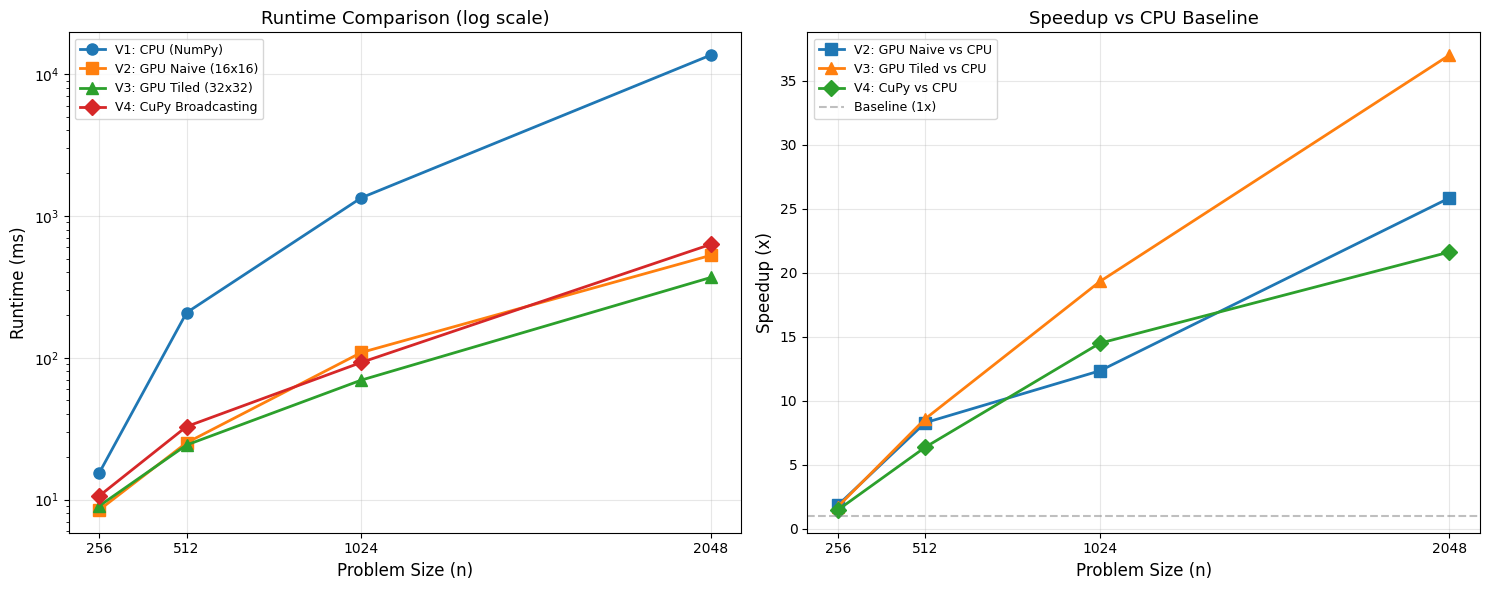

Plot saved as floyd_warshall_results.png


In [13]:
# ============================================================
# PLOTS: Runtime comparison and speedup charts
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sizes = problem_sizes
cpu_times = [results[n]['CPU (NumPy)'] for n in sizes]
naive_times = [results[n]['GPU Naive 16x16'] for n in sizes]
tiled_times = [results[n]['GPU Tiled 32x32'] for n in sizes]
cupy_times = [results[n]['CuPy Broadcasting'] for n in sizes]

# --- Left plot: Runtime (log scale) ---
ax1 = axes[0]
ax1.plot(sizes, cpu_times, 'o-', label='V1: CPU (NumPy)', linewidth=2, markersize=8)
ax1.plot(sizes, naive_times, 's-', label='V2: GPU Naive (16x16)', linewidth=2, markersize=8)
ax1.plot(sizes, tiled_times, '^-', label='V3: GPU Tiled (32x32)', linewidth=2, markersize=8)
ax1.plot(sizes, cupy_times, 'D-', label='V4: CuPy Broadcasting', linewidth=2, markersize=8)
ax1.set_xlabel('Problem Size (n)', fontsize=12)
ax1.set_ylabel('Runtime (ms)', fontsize=12)
ax1.set_title('Runtime Comparison (log scale)', fontsize=13)
ax1.set_yscale('log')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(sizes)

# --- Right plot: Speedup vs CPU ---
ax2 = axes[1]
naive_speedups = [cpu_times[i] / naive_times[i] for i in range(len(sizes))]
tiled_speedups = [cpu_times[i] / tiled_times[i] for i in range(len(sizes))]
cupy_speedups = [cpu_times[i] / cupy_times[i] for i in range(len(sizes))]

ax2.plot(sizes, naive_speedups, 's-', label='V2: GPU Naive vs CPU', linewidth=2, markersize=8)
ax2.plot(sizes, tiled_speedups, '^-', label='V3: GPU Tiled vs CPU', linewidth=2, markersize=8)
ax2.plot(sizes, cupy_speedups, 'D-', label='V4: CuPy vs CPU', linewidth=2, markersize=8)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline (1x)')
ax2.set_xlabel('Problem Size (n)', fontsize=12)
ax2.set_ylabel('Speedup (x)', fontsize=12)
ax2.set_title('Speedup vs CPU Baseline', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(sizes)

plt.tight_layout()
plt.savefig('floyd_warshall_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as floyd_warshall_results.png")